In [ ]:
!pip install matplotlib
!pip install numpy
!pip install scikit-learn seaborn joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import joblib 
import json
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)





In [ ]:
df = pd.read_csv('../data/synthetic_billing.csv')
print(df.shape)
print(df.head())

print(df.dtypes)

print(f"Total null values: {df.isnull().sum().sum()}")

print(df.describe())

In [ ]:
print(df['claim_status'].value_counts())

print("\nPercentage Distribution of claim_status: ")
print(df['claim_status'].value_counts(normalize=True))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='claim_status', data=df, ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Claim Status Distribution', fontsize=14)
axes[0].set_xlabel('Claim Status (0=Paid, 1=Denied)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Paid', 'Denied'])


status_counts = df['claim_status'].value_counts()
axes[1].pie(status_counts, labels=['Paid', 'Denied'], autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
axes[1].set_title('Claim Status Proportion', fontsize=14)

plt.tight_layout()
plt.show()

print("\nINSIGHT:")
denial_rate = (df['claim_status'].sum() / len(df)) * 100
print(f"Denial Rate: {denial_rate:.2f}%")
if denial_rate < 20:
    print(" Data is IMBALANCED - we'll use ROC-AUC as primary metric")
else:
    print(" Data is reasonably balanced")


In [ ]:
denial_by_insurance = df.groupby('insurance_type')['claim_status'].agg(['mean', 'count'])
denial_by_insurance.columns = ['Denial_Rate', 'Total_Claims']
denial_by_insurance['Denial_Rate'] = (denial_by_insurance['Denial_Rate'] * 100).round(2)
denial_by_insurance = denial_by_insurance.sort_values('Denial_Rate', ascending=False)
print("\nDenial Rate by Insurance Type:")
print(denial_by_insurance)


plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='insurance_type', y='claim_status', palette='rocket', order=denial_by_insurance.index, ci=None)
plt.title('Denial Rate by Insurance Type', fontsize=14)
plt.xlabel('Insurance Type')
plt.ylabel('Denial Rate ( 0 - 1 )')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nINSIGHT:")
highest_denial = denial_by_insurance.index[0]
highest_rate = denial_by_insurance.iloc[0]['Denial_Rate']
print(f"Insurance Type with Highest Denial Rate: {highest_denial} ({highest_rate}%)")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


for status, label, color in [(0, 'Paid', 'green'), (1, 'Denied', 'red')]:
    data = df[df['claim_status'] == status]['billed_amount']
    axes[0].hist(data, bins=50, alpha=0.6, label=label, color=color)
axes[0].set_title('Billed Amount Distribution by status', fontsize=14)
axes[0].set_xlabel('Billed Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


sns.barplot(data=df, x='claim_status', y='billed_amount', ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Billed Amount by Claim Status', fontsize=14)
axes[1].set_xticklabels(['Paid', 'Denied'])

plt.tight_layout()
plt.show()

print(f"Average amount PAID claims: ${df[df['claim_status']==0]['billed_amount'].mean():.2f}")
print(f"Average amount DENIED claims: ${df[df['claim_status']==1]['billed_amount'].mean():.2f}")

Feature Correlations

In [ ]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# print(numeric_features)

correlation = df[numeric_features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True, center=0, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation with Denial")
claim_corr = correlation['claim_status'].drop('claim_status').sort_values(ascending=False)
for feature, corr_value in claim_corr.items():
    direction = "Increases" if corr_value > 0 else "Decreases"
    print(f"{feature}: {corr_value:.2f} ({direction} Denial Probability)")

Feature Engineering

In [ ]:
df_model = df.copy()
drop_cols = ['patient_id', 'date', 'anomaly_label']
df_model = df_model.drop(columns=[col for col in drop_cols if col in df_model.columns]) #only drop if exists
# print(df_model.columns)

categorical_features = ['insurance_type', 'procedure_cpt_code', 'diagnosis_code']
df_encoded = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)
print(df_encoded.head(10))


In [ ]:
X = df_encoded.drop('claim_status', axis=1)
y = df_encoded['claim_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train.iloc[0, :5])
print(X_train_scaled[0, :5])
print("\n")
print(X_test.iloc[0, :5])
print(X_test_scaled[0, :5])


In [ ]:
# Train
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f" Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f" Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f" Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f" F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f" ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_lr):.4f}")



In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Paid (0)', 'Denied (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print(f"True Negatives (Correctly predicted PAID): {cm[0,0]}")
print(f"False Positives (Predicted DENIED, actually PAID): {cm[0,1]}")
print(f"False Negatives (Predicted PAID, actually DENIED): {cm[1,0]}")
print(f"True Positives (Correctly predicted DENIED): {cm[1,1]}")

# Business impact
print("\nBUSINESS IMPACT:")
print(f"Missed denials (False Negatives): {cm[1,0]} claims")
print(f"These claims will be submitted and DENIED, wasting resources")
print(f"False alarms (False Positives): {cm[0,1]} claims")
print(f"These claims flagged as risky but actually would have been PAID")

RANDOM FOREST

In [ ]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, n_jobs=-1)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\nPERFORMANCE METRICS:")
print(f"   Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"   F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}")


cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Paid (0)', 'Denied (1)'])
disp.plot(cmap='Greens', ax=ax, values_format='d')
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nComparison to Logistic Regression:")
print(f"   Accuracy change: {accuracy_score(y_test, y_pred_rf) - accuracy_score(y_test, y_pred_lr):+.4f}")
print(f"   ROC-AUC change: {roc_auc_score(y_test, y_pred_proba_rf) - roc_auc_score(y_test, y_pred_proba_lr):+.4f}")

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=5)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

print("\nGradient Boosting Performance:")
print(f"   Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred_gb):.4f}")
print(f"   F1-Score:  {f1_score(y_test, y_pred_gb):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_gb):.4f}")


cm_gb = confusion_matrix(y_test, y_pred_gb)
fig, ax = plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=['Paid (0)', 'Denied (1)'])
disp.plot(cmap='Oranges', ax=ax, values_format='d')
plt.title('Confusion Matrix - Gradient Boosting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

MODEL COMPARISON


                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     0.666     0.5915  0.2333    0.3347   0.5714
1        Random Forest     0.658     0.5882  0.1667    0.2597   0.5505
2    Gradient Boosting     0.657     0.5491  0.2639    0.3565   0.5710


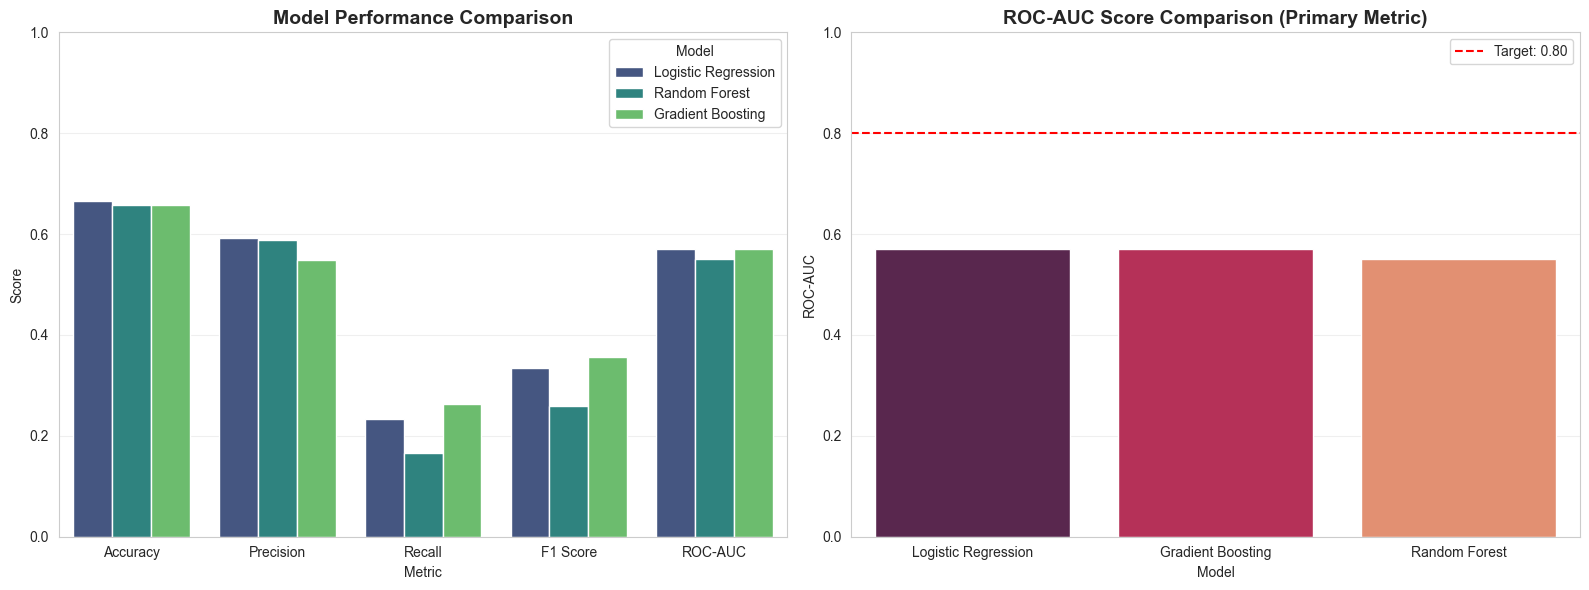

Best Model: Logistic Regression with ROC-AUC: 0.5714
Best ROC-AUC Score: 0.5714
The model is 14.3% better than random!


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_gb)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_gb)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_gb)],
    'F1 Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_gb)],
    'ROC-AUC': [roc_auc_score(y_test, y_pred_lr), roc_auc_score(y_test, y_pred_rf), roc_auc_score(y_test, y_pred_gb)]
})

print(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
comparison_melted = comparison.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Model', ax=axes[0], palette='viridis')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Model', loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

roc_data = comparison[['Model', 'ROC-AUC']].sort_values('ROC-AUC', ascending=False)
sns.barplot(data=roc_data, x='Model', y='ROC-AUC', palette='rocket', ax=axes[1])
axes[1].set_title('ROC-AUC Score Comparison (Primary Metric)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.8, color='red', linestyle='--', label='Target: 0.80')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


best_model_idx = comparison['ROC-AUC'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
best_auc = comparison.loc[best_model_idx, 'ROC-AUC']

print(f"Best Model: {best_model_name} with ROC-AUC: {best_auc:.4f}")
print(f"Best ROC-AUC Score: {best_auc:.4f}")
print(f"The model is {(best_auc - 0.5) / 0.5 * 100:.1f}% better than random")


ROC CURVE

In [ ]:
# this is for ROC curve false positive and true positive rates
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f"logistic regression (AUC = {roc_auc_score(y_test, y_pred_proba_lr):.4f})", color='blue')
plt.plot(fpr_rf, tpr_rf, label=f"random forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.4f})", color='green')
plt.plot(fpr_gb, tpr_gb, label=f"gradient boosting (AUC = {roc_auc_score(y_test, y_pred_proba_gb):.4f})", color='orange')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>